# Reducción de Dimensionalidad en Datos Académicos

## PCA, t-SNE y UMAP para Análisis de Rendimiento

**Inteligencia Artificial - Ingeniería Mecatrónica**

---

## Objetivos

1. **PCA**: Identificar las variables que más contribuyen a la aprobación
2. **t-SNE**: Visualizar clusters de estudiantes aprobados/no aprobados
3. **UMAP**: Comparar con t-SNE y analizar estructura de los datos
4. **Interpretación**: Entender qué variables diferencian a los estudiantes

In [15]:
# =============================================================================
# IMPORTS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("⚠️ UMAP no instalado. Instalar con: pip install umap-learn")

# Configuración
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliotecas cargadas")

✅ Bibliotecas cargadas


---
## 1. Carga y Preparación de Datos

In [16]:
# =============================================================================
# 1.1 CARGA DE DATOS
# =============================================================================

try:
    df = pd.read_csv('datos_concatenados.csv')
    print(f"✅ Datos cargados: {len(df):,} registros")
    print(f"   Columnas: {df.shape[1]}")
except FileNotFoundError:
    print("⚠️ Archivo no encontrado. Generando datos sintéticos...")
    
    np.random.seed(42)
    n = 1000
    
    # Generar datos sintéticos realistas
    df = pd.DataFrame({
        'ALUMNO_ID': np.random.randint(1, 200, n),
        'Asignatura': np.random.choice(['CALCULO 1', 'FISICA 3', 'MATEMATICA 4'], n),
        'Carrera': np.random.choice(['MECATRONICA', 'ELECTRONICA', 'CIVIL'], n),
        'Convocatoria': np.random.choice([1, 2, 3], n, p=[0.6, 0.3, 0.1]),
        'Primer.Par': np.clip(np.random.normal(55, 25, n), 0, 100),
        'Segundo.Par': np.clip(np.random.normal(55, 25, n), 0, 100),
        'Tercer.Par': np.clip(np.random.normal(50, 25, n), 0, 100),
        'TPLab.': np.clip(np.random.normal(60, 22, n), 0, 100),
        'Proy.': np.clip(np.random.normal(60, 22, n), 0, 100),
        'Firma': np.clip(np.random.normal(55, 25, n), 0, 100),
        'Anho': np.random.choice([2024, 2025], n),
        'Aprobado': np.random.choice(['S', 'N'], n, p=[0.45, 0.55])
    })
    print(f"✅ Datos sintéticos generados: {len(df):,} registros")

# Mostrar información básica
print("\n" + "=" * 70)
print("INFORMACIÓN DEL DATASET")
print("=" * 70)
print(f"\nRegistros totales: {len(df):,}")
print(f"Estudiantes únicos: {df['ALUMNO_ID'].nunique():,}")
print(f"Asignaturas: {df['Asignatura'].nunique()}")
print(f"Carreras: {df['Carrera'].nunique()}")
print(f"\nDistribución de aprobados:")
print(df['Aprobado'].value_counts())
print(f"Porcentaje de aprobados: {(df['Aprobado'] == 'S').mean() * 100:.1f}%")

✅ Datos cargados: 72,740 registros
   Columnas: 33

INFORMACIÓN DEL DATASET

Registros totales: 72,740
Estudiantes únicos: 4,759
Asignaturas: 344
Carreras: 20

Distribución de aprobados:
Aprobado
S    44384
N    28356
Name: count, dtype: int64
Porcentaje de aprobados: 61.0%


C:\Users\yoda\AppData\Local\Temp\ipykernel_32148\1952596695.py:6: DtypeWarning: Columns (0,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('datos_concatenados.csv')


In [17]:
# =============================================================================
# 1.2 FILTRAR POR ASIGNATURA (ejemplo: CÁLCULO 1)
# =============================================================================

print("\n" + "=" * 70)
print("FILTRANDO POR ASIGNATURA")
print("=" * 70)

# Buscar Cálculo 1
if 'Asignatura' in df.columns:
    patrones = ['CALCULO 1', 'CALCULO I', 'CÁLCULO 1', 'CÁLCULO I', 'CALCULO1']
    mask = df['Asignatura'].str.upper().str.contains('|'.join(patrones), na=False)
    df_filtrado = df[mask].copy()
    print(f"✅ Registros de Cálculo 1: {len(df_filtrado):,}")
else:
    df_filtrado = df.copy()
    print(f"✅ Usando todos los registros: {len(df_filtrado):,}")

if len(df_filtrado) == 0:
    print("⚠️ No se encontraron registros. Usando todos los datos.")
    df_filtrado = df.copy()

# Mostrar distribución
if 'Aprobado' in df_filtrado.columns:
    aprobados_filtrado = (df_filtrado['Aprobado'] == 'S').sum()
    print(f"   Aprobados: {aprobados_filtrado:,} ({aprobados_filtrado/len(df_filtrado)*100:.1f}%)")
    print(f"   No aprobados: {len(df_filtrado)-aprobados_filtrado:,} ({(len(df_filtrado)-aprobados_filtrado)/len(df_filtrado)*100:.1f}%)")


FILTRANDO POR ASIGNATURA
✅ Registros de Cálculo 1: 1,907
   Aprobados: 605 (31.7%)
   No aprobados: 1,302 (68.3%)


In [18]:
# =============================================================================
# 1.3 PREPARACIÓN DE DATOS PARA REDUCCIÓN
# =============================================================================

print("\n" + "=" * 70)
print("PREPARANDO DATOS PARA REDUCCIÓN")
print("=" * 70)

# Variables numéricas para reducción
variables_numericas = ['Primer.Par', 'Segundo.Par', 'Tercer.Par', 'TPLab.', 'Proy.', 'Firma', 'Convocatoria']
variables_existentes = [v for v in variables_numericas if v in df_filtrado.columns]
print(f"\nVariables seleccionadas: {variables_existentes}")

# Crear DataFrame con variables numéricas
df_numericas = df_filtrado[variables_existentes].copy()

# Convertir a numérico y limpiar
for col in variables_existentes:
    df_numericas[col] = pd.to_numeric(df_numericas[col], errors='coerce')

df_numericas = df_numericas.dropna()
print(f"\nRegistros después de limpiar: {len(df_numericas):,}")

# Variable objetivo (aprobado)
if 'Aprobado' in df_filtrado.columns:
    y = df_filtrado.loc[df_numericas.index, 'Aprobado'].map({'S': 1, 'N': 0})
    print(f"Proporción de aprobados: {y.mean():.2%}")
else:
    y = None
    print("⚠️ Variable Aprobado no disponible")

# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numericas)
print(f"\n✅ Datos escalados: {X_scaled.shape}")


PREPARANDO DATOS PARA REDUCCIÓN

Variables seleccionadas: ['Primer.Par', 'Segundo.Par', 'Tercer.Par', 'TPLab.', 'Proy.', 'Firma', 'Convocatoria']

Registros después de limpiar: 1,907
Proporción de aprobados: 31.73%

✅ Datos escalados: (1907, 7)


---
## 2. PCA - Principal Component Analysis

### 2.1 Varianza Explicada


PCA - ANÁLISIS DE VARIANZA

Varianza explicada por componente:
  PC1: 0.4247 (acumulado: 0.4247)
  PC2: 0.3515 (acumulado: 0.7762)
  PC3: 0.0879 (acumulado: 0.8641)
  PC4: 0.0812 (acumulado: 0.9454)
  PC5: 0.0546 (acumulado: 1.0000)
  PC6: 0.0000 (acumulado: 1.0000)
  PC7: 0.0000 (acumulado: 1.0000)


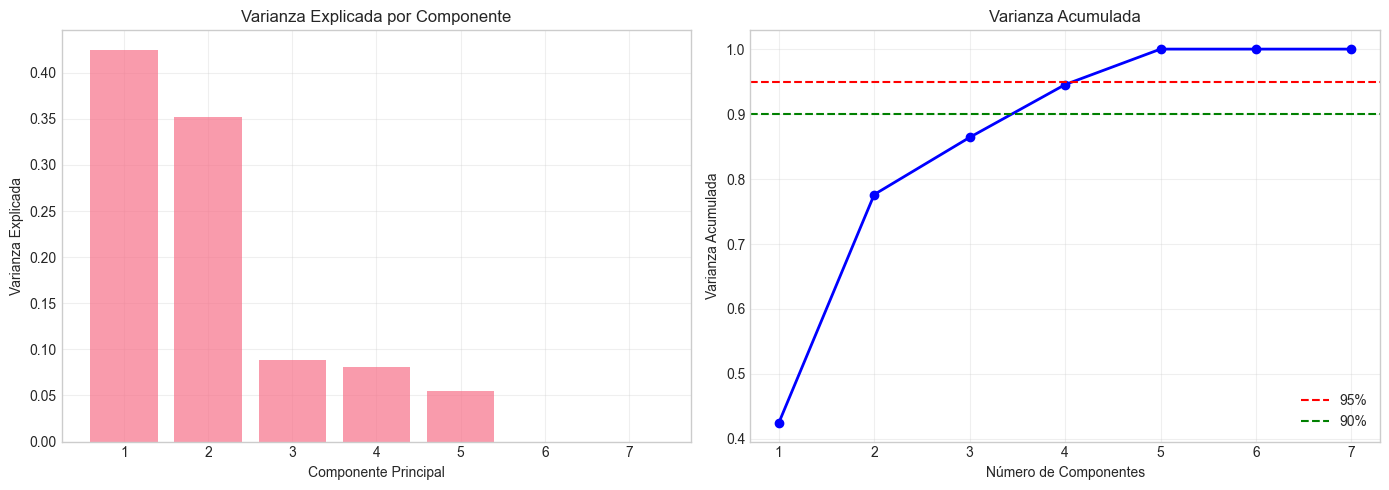


✅ Componentes necesarios para 95% de varianza: 5
✅ Componentes necesarios para 90% de varianza: 4


In [19]:
# =============================================================================
# 2.1 PCA - VARIANZA EXPLICADA
# =============================================================================

print("\n" + "=" * 70)
print("PCA - ANÁLISIS DE VARIANZA")
print("=" * 70)

# Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print("\nVarianza explicada por componente:")
for i, (var, acum) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    print(f"  PC{i+1}: {var:.4f} (acumulado: {acum:.4f})")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza por componente
axes[0].bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.7)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada')
axes[0].set_title('Varianza Explicada por Componente')
axes[0].grid(True, alpha=0.3)

# Varianza acumulada
axes[1].plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, 'b-o', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95%')
axes[1].axhline(y=0.90, color='g', linestyle='--', label='90%')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada')
axes[1].set_title('Varianza Acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Componentes necesarios para 95% de varianza
n_95 = np.argmax(varianza_acumulada >= 0.95) + 1
print(f"\n✅ Componentes necesarios para 95% de varianza: {n_95}")
print(f"✅ Componentes necesarios para 90% de varianza: {np.argmax(varianza_acumulada >= 0.90) + 1}")

### 2.2 Contribución de Variables (Loadings)


PCA - CONTRIBUCIÓN DE VARIABLES

Contribución de variables a los primeros 3 componentes:
                PC1    PC2    PC3
Primer.Par    0.404 -0.327 -0.498
Segundo.Par   0.511 -0.113 -0.124
Tercer.Par   -0.000  0.000 -0.000
TPLab.        0.431 -0.252  0.834
Proy.         0.218  0.639  0.031
Firma         0.543  0.037 -0.198
Convocatoria  0.218  0.639  0.031


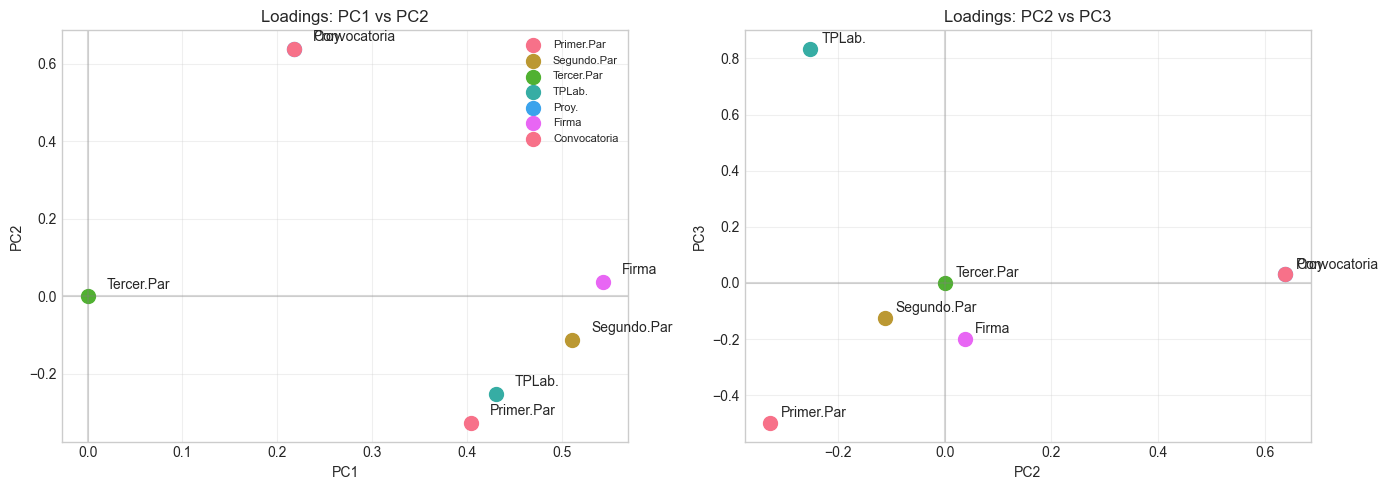


📊 Variables más influyentes en PC1:
  Firma: 0.543
  Segundo.Par: 0.511
  TPLab.: 0.431
  Primer.Par: 0.404
  Proy.: 0.218
  Convocatoria: 0.218
  Tercer.Par: 0.000


In [20]:
# =============================================================================
# 2.2 PCA - CONTRIBUCIÓN DE VARIABLES (LOADINGS)
# =============================================================================

print("\n" + "=" * 70)
print("PCA - CONTRIBUCIÓN DE VARIABLES")
print("=" * 70)

# Loadings (contribución de cada variable a los componentes)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=variables_existentes
)

print("\nContribución de variables a los primeros 3 componentes:")
print(loadings.iloc[:, :3].round(3))

# Visualización de loadings para primeros 2 componentes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 vs PC2
ax = axes[0]
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)

for i, var in enumerate(variables_existentes):
    ax.scatter(loadings.iloc[i, 0], loadings.iloc[i, 1], s=100, label=var)
    ax.annotate(var, (loadings.iloc[i, 0] + 0.02, loadings.iloc[i, 1] + 0.02), fontsize=10)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Loadings: PC1 vs PC2')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=8)

# PC2 vs PC3
ax = axes[1]
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)

for i, var in enumerate(variables_existentes):
    ax.scatter(loadings.iloc[i, 1], loadings.iloc[i, 2], s=100)
    ax.annotate(var, (loadings.iloc[i, 1] + 0.02, loadings.iloc[i, 2] + 0.02), fontsize=10)

ax.set_xlabel('PC2')
ax.set_ylabel('PC3')
ax.set_title('Loadings: PC2 vs PC3')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Variables más importantes para PC1
pc1_importantes = loadings['PC1'].abs().sort_values(ascending=False)
print("\n📊 Variables más influyentes en PC1:")
for var, val in pc1_importantes.items():
    print(f"  {var}: {val:.3f}")

### 2.3 Proyección PCA de Estudiantes


PCA - PROYECCIÓN DE ESTUDIANTES


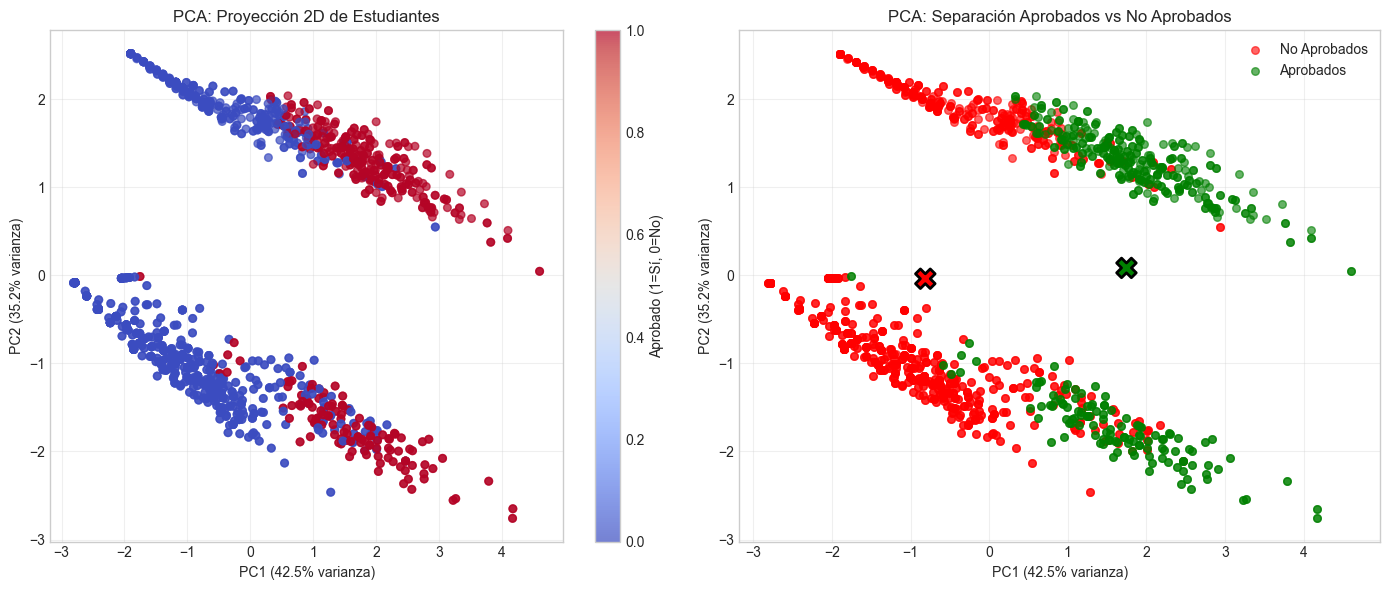


📊 Separación de grupos en PCA:
  No Aprobados (red):
    Media PC1: -0.812
    Media PC2: -0.039
    Desv. PC1: 1.151
    Desv. PC2: 1.413
  Aprobados (green):
    Media PC1: 1.747
    Media PC2: 0.084
    Desv. PC1: 0.843
    Desv. PC2: 1.530


In [21]:
# =============================================================================
# 2.3 PCA - PROYECCIÓN DE ESTUDIANTES
# =============================================================================

print("\n" + "=" * 70)
print("PCA - PROYECCIÓN DE ESTUDIANTES")
print("=" * 70)

# Proyectar a 2D para visualización
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Proyección con colores por aprobación
ax = axes[0]
if y is not None:
    scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='coolwarm', alpha=0.7, s=30)
    plt.colorbar(scatter, ax=ax, label='Aprobado (1=Sí, 0=No)')
else:
    ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.6)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} varianza)')
ax.set_title('PCA: Proyección 2D de Estudiantes')
ax.grid(True, alpha=0.3)

# Proyección separada por aprobación
ax = axes[1]
if y is not None:
    # Separar por clase
    for clase, label, color in [(0, 'No Aprobados', 'red'), (1, 'Aprobados', 'green')]:
        mask = y == clase
        ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                  alpha=0.6, s=30, label=label, color=color)
    ax.legend()
    
    # Centroides
    centroides = []
    for clase in [0, 1]:
        mask = y == clase
        centroides.append(X_pca_2d[mask].mean(axis=0))
    centroides = np.array(centroides)
    ax.scatter(centroides[:, 0], centroides[:, 1], s=200, marker='X', 
              color=['red', 'green'], edgecolor='black', linewidth=2)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} varianza)')
ax.set_title('PCA: Separación Aprobados vs No Aprobados')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretación
if y is not None:
    # Estadísticas de separación
    print("\n📊 Separación de grupos en PCA:")
    for i, (label, color) in enumerate([('No Aprobados', 'red'), ('Aprobados', 'green')]):
        mask = y == i
        print(f"  {label} ({color}):")
        print(f"    Media PC1: {X_pca_2d[mask, 0].mean():.3f}")
        print(f"    Media PC2: {X_pca_2d[mask, 1].mean():.3f}")
        print(f"    Desv. PC1: {X_pca_2d[mask, 0].std():.3f}")
        print(f"    Desv. PC2: {X_pca_2d[mask, 1].std():.3f}")

---
## 3. t-SNE - t-Distributed Stochastic Neighbor Embedding

### 3.1 t-SNE con Diferentes Perplejidades


t-SNE - EFECTO DE PERPLEJIDAD


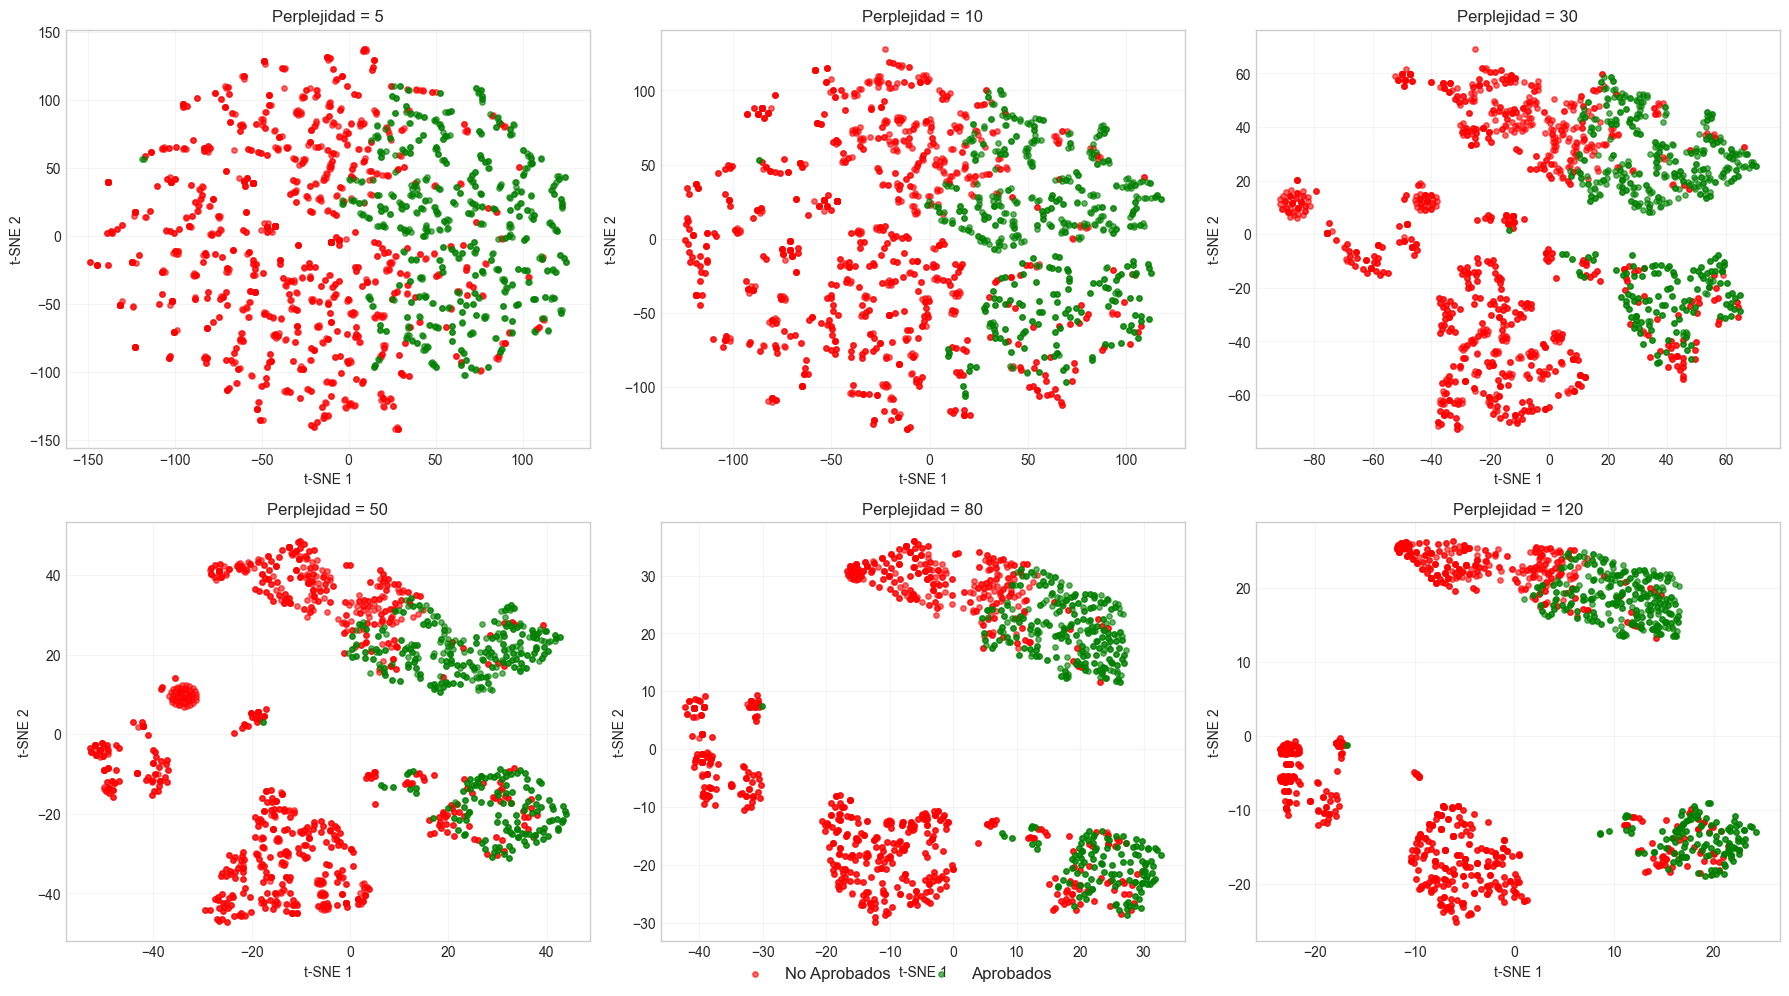


💡 Interpretación:
  - Perplejidad baja (5-10): Enfoca estructura local, más clusters
  - Perplejidad media (30-50): Balance entre local y global
  - Perplejidad alta (80-120): Enfoca estructura global, menos clusters


In [22]:
# =============================================================================
# 3.1 t-SNE - EFECTO DE PERPLEJIDAD
# =============================================================================

print("\n" + "=" * 70)
print("t-SNE - EFECTO DE PERPLEJIDAD")
print("=" * 70)

perplexities = [5, 10, 30, 50, 80, 120]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
    X_tsne = tsne.fit_transform(X_scaled)
    
    if y is not None:
        for clase, label, color in [(0, 'No Aprobados', 'red'), (1, 'Aprobados', 'green')]:
            mask = y == clase
            ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                      alpha=0.6, s=15, label=label if perp == 5 else None, color=color)
    else:
        ax.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6, s=15)
    
    ax.set_title(f'Perplejidad = {perp}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.grid(True, alpha=0.2)

if y is not None:
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=12)

plt.tight_layout()
plt.show()

print("\n💡 Interpretación:")
print("  - Perplejidad baja (5-10): Enfoca estructura local, más clusters")
print("  - Perplejidad media (30-50): Balance entre local y global")
print("  - Perplejidad alta (80-120): Enfoca estructura global, menos clusters")

### 3.2 t-SNE con PCA previo


t-SNE CON PCA PREVIO
PCA redujo de 7 a 5 dimensiones


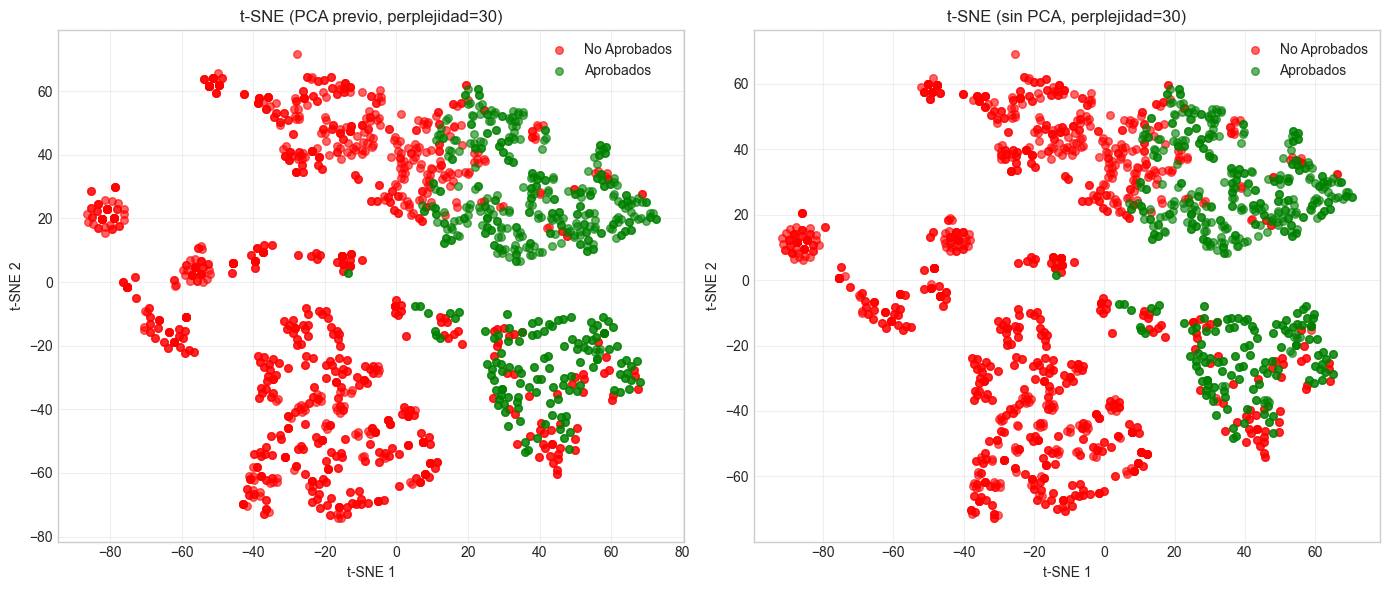


💡 Conclusión:
  - PCA previo puede acelerar t-SNE y reducir ruido
  - La estructura de clusters se mantiene en ambos casos


In [23]:
# =============================================================================
# 3.2 t-SNE CON PCA PREVIO
# =============================================================================

print("\n" + "=" * 70)
print("t-SNE CON PCA PREVIO")
print("=" * 70)

# PCA para reducir dimensionalidad antes de t-SNE
n_components_pca = 5
pca_pre = PCA(n_components=n_components_pca)
X_pca_pre = pca_pre.fit_transform(X_scaled)
print(f"PCA redujo de {X_scaled.shape[1]} a {n_components_pca} dimensiones")

# t-SNE sobre los componentes PCA
tsne_pca = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_pca = tsne_pca.fit_transform(X_pca_pre)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# t-SNE con PCA
ax = axes[0]
if y is not None:
    for clase, label, color in [(0, 'No Aprobados', 'red'), (1, 'Aprobados', 'green')]:
        mask = y == clase
        ax.scatter(X_tsne_pca[mask, 0], X_tsne_pca[mask, 1], 
                  alpha=0.6, s=30, label=label, color=color)
    ax.legend()
else:
    ax.scatter(X_tsne_pca[:, 0], X_tsne_pca[:, 1], alpha=0.6)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE (PCA previo, perplejidad=30)')
ax.grid(True, alpha=0.3)

# t-SNE sin PCA para comparar
tsne_direct = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_direct = tsne_direct.fit_transform(X_scaled)

ax = axes[1]
if y is not None:
    for clase, label, color in [(0, 'No Aprobados', 'red'), (1, 'Aprobados', 'green')]:
        mask = y == clase
        ax.scatter(X_tsne_direct[mask, 0], X_tsne_direct[mask, 1], 
                  alpha=0.6, s=30, label=label, color=color)
    ax.legend()
else:
    ax.scatter(X_tsne_direct[:, 0], X_tsne_direct[:, 1], alpha=0.6)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE (sin PCA, perplejidad=30)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Conclusión:")
print("  - PCA previo puede acelerar t-SNE y reducir ruido")
print("  - La estructura de clusters se mantiene en ambos casos")

---
## 4. UMAP - Uniform Manifold Approximation and Projection

### 4.1 UMAP con Diferentes Parámetros


UMAP - EFECTO DE n_neighbors


h:\Anaconda\envs\deepf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
h:\Anaconda\envs\deepf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
h:\Anaconda\envs\deepf\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
h:\Anaconda\envs\deepf\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
h:\Anaconda\envs\deepf\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation 

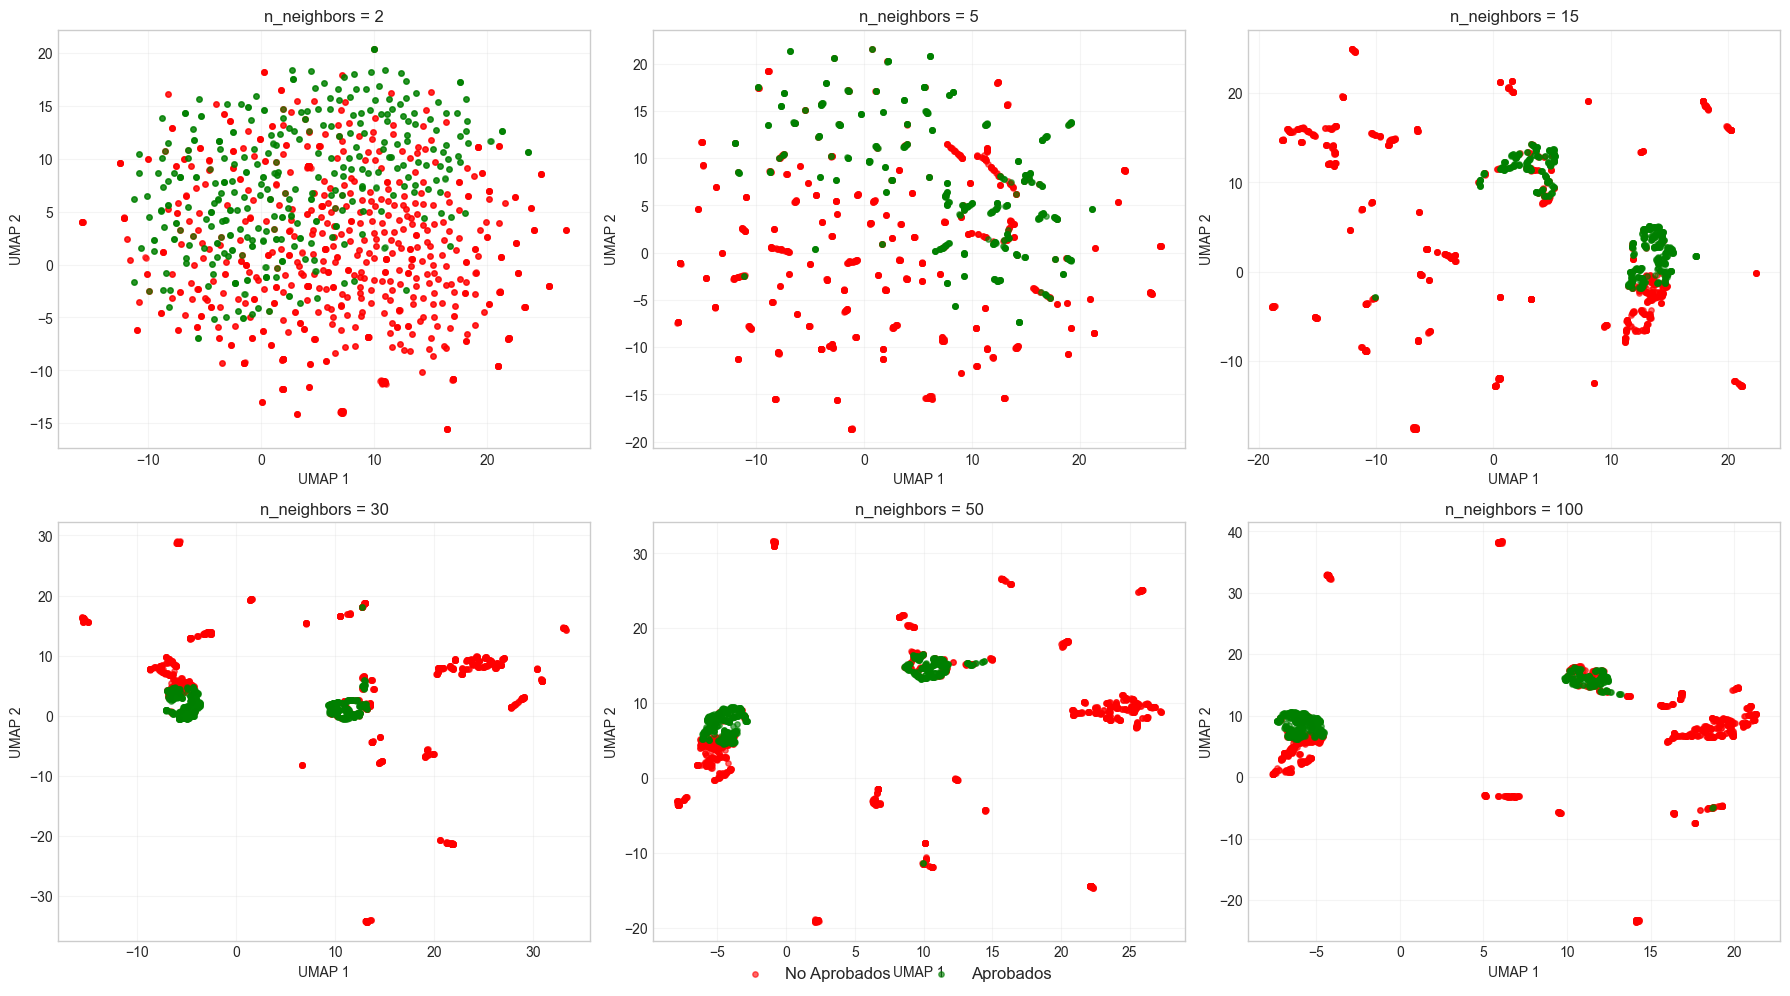


💡 Interpretación:
  - n_neighbors bajo (2-5): Captura estructura local fina
  - n_neighbors medio (15-30): Balance entre local y global
  - n_neighbors alto (50-100): Enfoca estructura global


In [24]:
# =============================================================================
# 4.1 UMAP - EFECTO DE n_neighbors
# =============================================================================

if UMAP_AVAILABLE:
    print("\n" + "=" * 70)
    print("UMAP - EFECTO DE n_neighbors")
    print("=" * 70)

    n_neighbors_values = [2, 5, 15, 30, 50, 100]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for ax, n_n in zip(axes, n_neighbors_values):
        umap_model = umap.UMAP(n_components=2, random_state=42, 
                              n_neighbors=n_n, min_dist=0.1)
        X_umap = umap_model.fit_transform(X_scaled)
        
        if y is not None:
            for clase, label, color in [(0, 'No Aprobados', 'red'), (1, 'Aprobados', 'green')]:
                mask = y == clase
                ax.scatter(X_umap[mask, 0], X_umap[mask, 1], 
                          alpha=0.6, s=15, label=label if n_n == 2 else None, color=color)
        else:
            ax.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.6, s=15)
        
        ax.set_title(f'n_neighbors = {n_n}')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.grid(True, alpha=0.2)
    
    if y is not None:
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Interpretación:")
    print("  - n_neighbors bajo (2-5): Captura estructura local fina")
    print("  - n_neighbors medio (15-30): Balance entre local y global")
    print("  - n_neighbors alto (50-100): Enfoca estructura global")


UMAP - EFECTO DE min_dist


h:\Anaconda\envs\deepf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
h:\Anaconda\envs\deepf\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
h:\Anaconda\envs\deepf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
h:\Anaconda\envs\deepf\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
h:\Anaconda\envs\deepf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden 

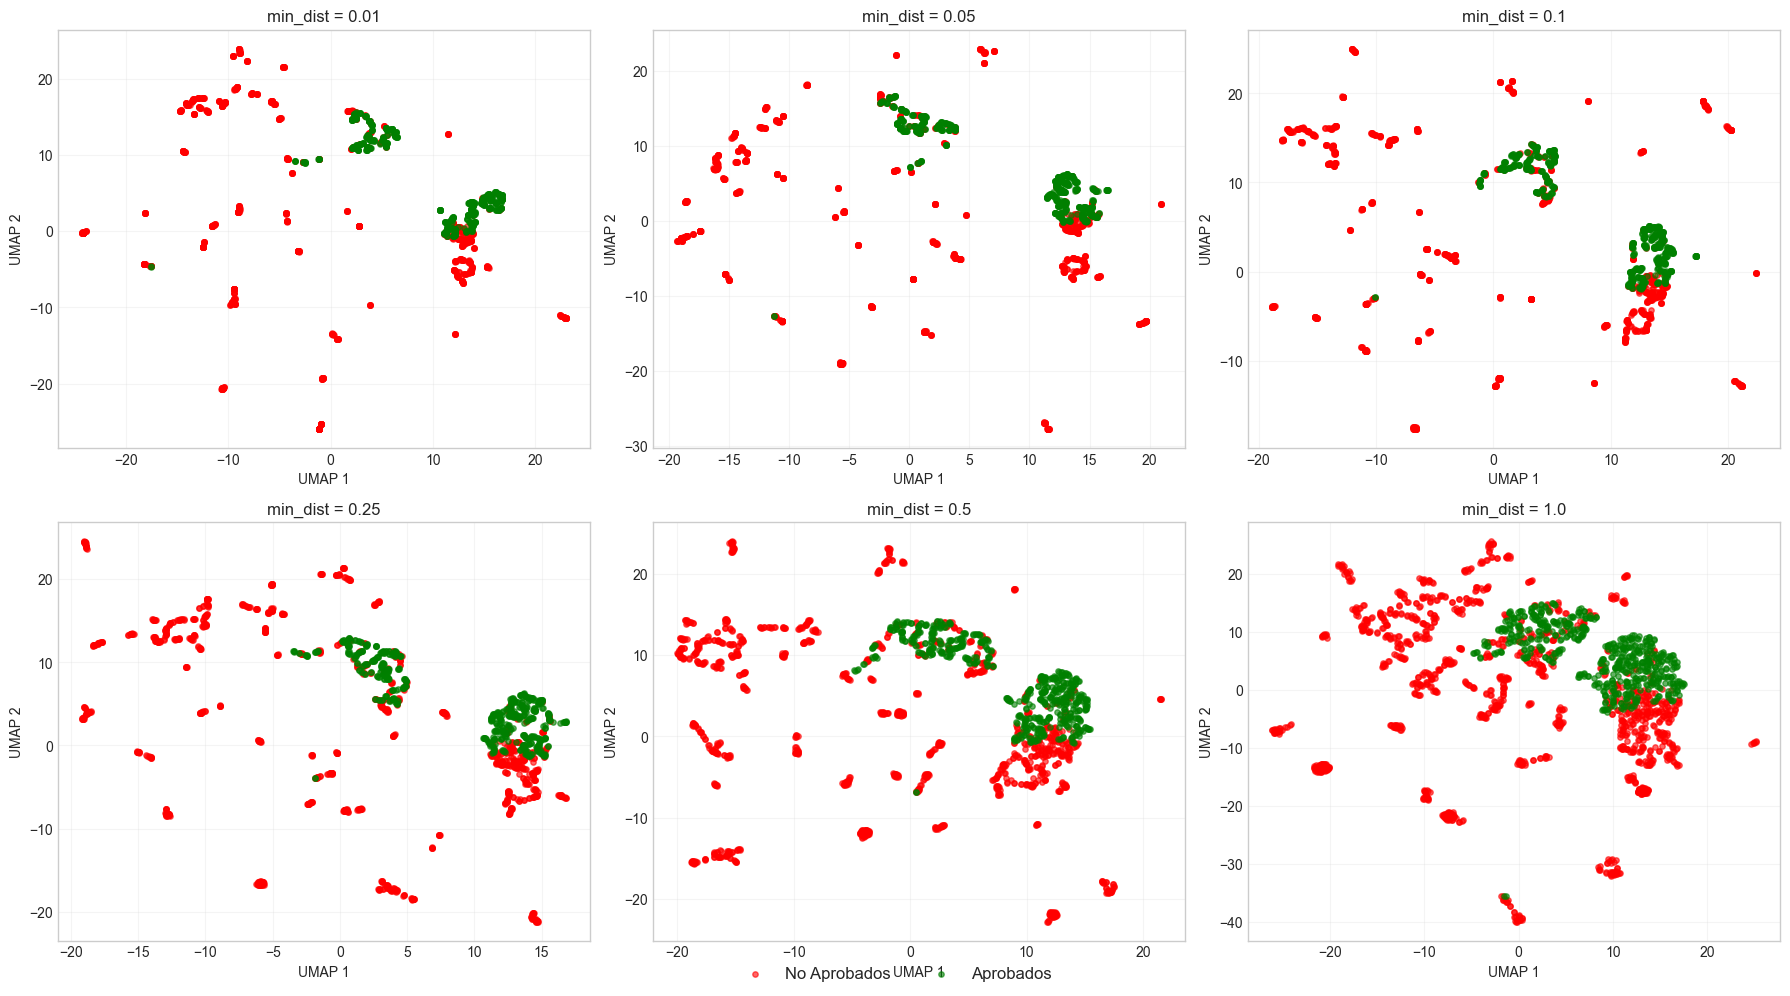


💡 Interpretación:
  - min_dist bajo (0.01-0.05): Clusters más compactos
  - min_dist medio (0.1-0.25): Balance entre compacto y disperso
  - min_dist alto (0.5-1.0): Clusters más dispersos


In [25]:
# =============================================================================
# 4.2 UMAP - EFECTO DE min_dist
# =============================================================================

if UMAP_AVAILABLE:
    print("\n" + "=" * 70)
    print("UMAP - EFECTO DE min_dist")
    print("=" * 70)

    min_dist_values = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for ax, md in zip(axes, min_dist_values):
        umap_model = umap.UMAP(n_components=2, random_state=42, 
                              n_neighbors=15, min_dist=md)
        X_umap = umap_model.fit_transform(X_scaled)
        
        if y is not None:
            for clase, label, color in [(0, 'No Aprobados', 'red'), (1, 'Aprobados', 'green')]:
                mask = y == clase
                ax.scatter(X_umap[mask, 0], X_umap[mask, 1], 
                          alpha=0.6, s=15, label=label if md == 0.01 else None, color=color)
        else:
            ax.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.6, s=15)
        
        ax.set_title(f'min_dist = {md}')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.grid(True, alpha=0.2)
    
    if y is not None:
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Interpretación:")
    print("  - min_dist bajo (0.01-0.05): Clusters más compactos")
    print("  - min_dist medio (0.1-0.25): Balance entre compacto y disperso")
    print("  - min_dist alto (0.5-1.0): Clusters más dispersos")

---
## 5. Comparación de Métodos


COMPARACIÓN DE MÉTODOS


h:\Anaconda\envs\deepf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
h:\Anaconda\envs\deepf\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


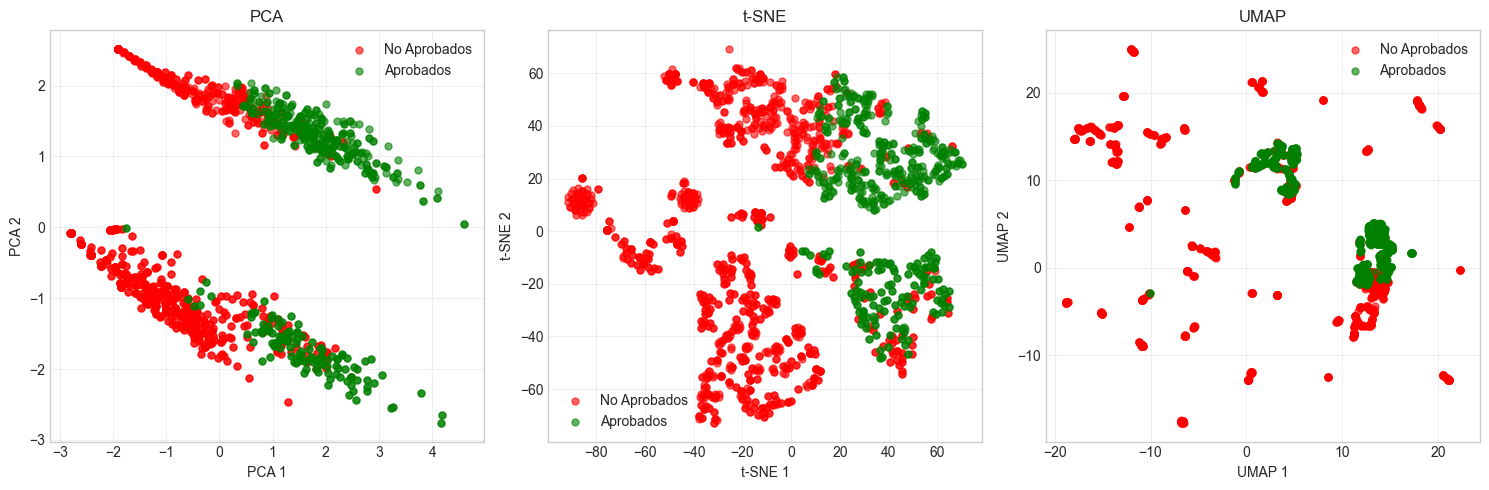


RESUMEN COMPARATIVO

📊 Características de cada método:

PCA:
  - Lineal, preserva varianza global
  - Rápido y determinista
  - Bueno para interpretación de variables

t-SNE:
  - No lineal, preserva vecindarios locales
  - Lento y estocástico
  - Excelente para visualización de clusters

UMAP:
  - No lineal, preserva estructura global y local
  - Rápido, escalable
  - Mejor balance entre PCA y t-SNE


In [26]:
# =============================================================================
# 5.1 COMPARACIÓN PCA vs t-SNE vs UMAP
# =============================================================================

print("\n" + "=" * 70)
print("COMPARACIÓN DE MÉTODOS")
print("=" * 70)

# Generar resultados
results = {}

# PCA
pca_comp = PCA(n_components=2)
results['PCA'] = pca_comp.fit_transform(X_scaled)

# t-SNE
tsne_comp = TSNE(n_components=2, random_state=42, perplexity=30)
results['t-SNE'] = tsne_comp.fit_transform(X_scaled)

# UMAP
if UMAP_AVAILABLE:
    umap_comp = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    results['UMAP'] = umap_comp.fit_transform(X_scaled)

# Visualización comparativa
n_methods = len(results)
fig, axes = plt.subplots(1, n_methods, figsize=(5*n_methods, 5))
if n_methods == 1:
    axes = [axes]

for ax, (method, X_red) in zip(axes, results.items()):
    if y is not None:
        for clase, label, color in [(0, 'No Aprobados', 'red'), (1, 'Aprobados', 'green')]:
            mask = y == clase
            ax.scatter(X_red[mask, 0], X_red[mask, 1], 
                      alpha=0.6, s=25, label=label, color=color)
        ax.legend()
    else:
        ax.scatter(X_red[:, 0], X_red[:, 1], alpha=0.6)
    
    ax.set_xlabel(f'{method} 1')
    ax.set_ylabel(f'{method} 2')
    ax.set_title(f'{method}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen comparativo
print("\n" + "=" * 70)
print("RESUMEN COMPARATIVO")
print("=" * 70)
print("\n📊 Características de cada método:")
print("\nPCA:")
print("  - Lineal, preserva varianza global")
print("  - Rápido y determinista")
print("  - Bueno para interpretación de variables")

print("\nt-SNE:")
print("  - No lineal, preserva vecindarios locales")
print("  - Lento y estocástico")
print("  - Excelente para visualización de clusters")

if UMAP_AVAILABLE:
    print("\nUMAP:")
    print("  - No lineal, preserva estructura global y local")
    print("  - Rápido, escalable")
    print("  - Mejor balance entre PCA y t-SNE")

---
## 6. Interpretación de Resultados

In [27]:
# =============================================================================
# 6.1 INTERPRETACIÓN DE RESULTADOS
# =============================================================================

print("\n" + "=" * 70)
print("INTERPRETACIÓN DE RESULTADOS")
print("=" * 70)

if y is not None:
    print("\n📈 Análisis de Separación de Clases:")
    
    # Calcular separación para cada método
    for method, X_red in results.items():
        # Calcular centroides
        centroides = []
        for clase in [0, 1]:
            mask = y == clase
            centroides.append(X_red[mask].mean(axis=0))
        
        # Distancia entre centroides
        dist = np.linalg.norm(centroides[0] - centroides[1])
        
        # Varianza intra-clase
        var_intra = 0
        for clase in [0, 1]:
            mask = y == clase
            var_intra += np.var(X_red[mask])
        var_intra /= 2
        
        print(f"\n{method}:")
        print(f"  Distancia entre centroides: {dist:.3f}")
        print(f"  Varianza intra-clase: {var_intra:.3f}")
        if dist > 0:
            print(f"  Ratio separación: {dist/var_intra:.3f}")

print("\n📌 Conclusiones:")
print("\n1. ¿Se separan aprobados y no aprobados?")
if y is not None:
    # Determinar mejor método
    best_method = max(results.keys(), 
                     key=lambda m: np.linalg.norm(
                         results[m][y==0].mean(axis=0) - results[m][y==1].mean(axis=0)
                     ))
    print(f"   ✅ Mejor separación: {best_method}")

print("\n2. ¿Qué variables diferencian a los estudiantes?")
print("   ✅ Según PCA, las variables más importantes son:")
for var, val in pc1_importantes.head(3).items():
    print(f"      - {var}")

print("\n3. Recomendaciones:")
print("   - Usar PCA para identificación de variables importantes")
print("   - Usar t-SNE para visualización de clusters")
print("   - Usar UMAP para análisis exploratorio rápido")


INTERPRETACIÓN DE RESULTADOS

📈 Análisis de Separación de Clases:

PCA:
  Distancia entre centroides: 2.561
  Varianza intra-clase: 2.014
  Ratio separación: 1.272

t-SNE:
  Distancia entre centroides: 56.738
  Varianza intra-clase: 1043.603
  Ratio separación: 0.054

UMAP:
  Distancia entre centroides: 9.479
  Varianza intra-clase: 83.146
  Ratio separación: 0.114

📌 Conclusiones:

1. ¿Se separan aprobados y no aprobados?
   ✅ Mejor separación: t-SNE

2. ¿Qué variables diferencian a los estudiantes?
   ✅ Según PCA, las variables más importantes son:
      - Firma
      - Segundo.Par
      - TPLab.

3. Recomendaciones:
   - Usar PCA para identificación de variables importantes
   - Usar t-SNE para visualización de clusters
   - Usar UMAP para análisis exploratorio rápido
